# 09 Reentrainement sur la cible retenue

**Auteur : Jules Mortreux. Branche : `explo-jules`.**

Le notebook 08 a compare cinq definitions candidates de la qualite d'une soudure
et conclu qu'il fallait retenir `y3`, la moyenne geometrique du rang de
resistance et du rang de ductilite, construite sur quatre mesures de traction au
lieu de deux. Il a produit le jeu de donnees correspondant,
`outputs/08/dataset_traction_y3.csv`.

Ce notebook en tire les consequences : il **refait la modelisation sur la
nouvelle cible et compare point par point avec les resultats obtenus sur
l'ancienne.**

## Ce que ce notebook cherche a etablir

Trois questions, dans cet ordre.

**1. Qu'est-ce qui change vraiment ?** Changer la cible ne change pas les
variables d'entree. Il faut donc verifier lesquelles des etapes precedentes sont
reellement affectees, et lesquelles ne le sont pas. Refaire un travail qui donne
le meme resultat n'a aucun interet ; passer a cote d'un travail qui change
silencieusement serait une faute.

**2. Les modeles font-ils mieux ou moins bien sur la nouvelle cible ?** La
section 4 du notebook 08 avait deja donne une indication favorable, mais avec un
seul modele et un seul jeu d'hyperparametres. Ici on reprend les grilles
completes des notebooks 05 et 06.

**3. Le classement des modeles est-il bouleverse ?** Si la forêt aleatoire
restait le meilleur modele, les conclusions de l'equipe sur le choix du modele
tiendraient malgre le changement de cible. Sinon, il faudrait les reprendre.

## Ce que ce notebook ne refait pas, et pourquoi

Il ne reprend pas les parties exploratoires des notebooks 03 a 07 : pourquoi
imputer par la mediane, comment fonctionne une analyse en composantes
principales, pourquoi une forêt reduit la variance d'un arbre. Ces
developpements ne dependent pas de la cible et restent valables tels quels.

Il ne modifie aucun notebook existant. Les resultats sur l'ancienne cible sont
conserves et relus depuis leurs fichiers de sortie, pour etre presentes en
regard des nouveaux. Le projet garde ainsi la trace des deux etats.

## Protocole : tout est fixe sauf la cible

Pour que la comparaison ait un sens, tout ce qui peut etre tenu constant l'est.

- **Meme separation developpement/test**, verifiee identique a celle du
  notebook 02 ligne par ligne.
- **Memes plis de validation croisee** : `GroupKFold` a cinq plis sur la colonne
  `groupe`, donc aucune soudure a cheval sur l'apprentissage et la validation.
- **Memes grilles d'hyperparametres** que les notebooks 05 et 06, aux memes
  valeurs.
- **Memes metriques**, ponderees par soudure.
- **Meme graine aleatoire**, 42.
- **Meme recalibrage de la cible dans chaque pli**, comme le faisait le
  notebook 06 : les rangs sont recalcules sur l'apprentissage du pli
  uniquement.

In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn import __version__ as version_sklearn
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, silhouette_score)
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "outputs" / "09"
OUT.mkdir(parents=True, exist_ok=True)

GRAINE = 42
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
pd.set_option("display.max_colwidth", None)

print("scikit-learn", version_sklearn)
print("sorties dans", OUT.relative_to(ROOT))

scikit-learn 1.7.2
sorties dans outputs\09


## 1. Les deux jeux de donnees

On charge l'ancien et le nouveau. Le premier vient du notebook 02 et porte la
cible a deux mesures ; le second vient du notebook 08 et porte la cible a
quatre mesures. Les deux ont la meme structure et le meme nom de colonne de
cible, `score_compromis`, ce qui est precisement ce qui permet de reutiliser le
code existant sans le reecrire.

In [2]:
lecture = dict(index_col="row_id",
               dtype={c: str for c in ["AC_DC", "Electrode_pol", "WeldType",
                                       "WeldID"]},
               keep_default_na=False, na_values=[""],
               float_precision="round_trip")

ancien = pd.read_csv(ROOT / "outputs/02/dataset_traction.csv", **lecture)
nouveau = pd.read_csv(ROOT / "outputs/08/dataset_traction_y3.csv", **lecture)

RESISTANCE = ["YieldStrength_MPa", "UTS_MPa"]
DUCTILITE = ["Elongation_pct", "ReductionArea_pct"]
MESURES = RESISTANCE + DUCTILITE
CATEGORIES = ["AC_DC", "Electrode_pol", "WeldType"]

# Les variables d'entree sont les memes dans les deux jeux : composition et
# procede. On les deduit de l'ancien jeu pour etre sur de ne rien ajouter.
VARIABLES = [c for c in ancien.columns
             if c not in ["groupe", "partition", "WeldID", "score_compromis",
                          "UTS_MPa", "Elongation_pct"]]

communes = ancien.index.intersection(nouveau.index)
assert (ancien.loc[communes, "partition"]
        == nouveau.loc[communes, "partition"]).all(), "partitions differentes"
assert set(VARIABLES).issubset(nouveau.columns)

presentation = pd.DataFrame({
    "ancienne cible y2": {
        "mesures combinees": 2,
        "lignes": len(ancien),
        "soudures": ancien["groupe"].nunique(),
        "developpement": int((ancien["partition"] == "developpement").sum()),
        "test": int((ancien["partition"] == "test").sum()),
    },
    "nouvelle cible y3": {
        "mesures combinees": len(MESURES),
        "lignes": len(nouveau),
        "soudures": nouveau["groupe"].nunique(),
        "developpement": int((nouveau["partition"] == "developpement").sum()),
        "test": int((nouveau["partition"] == "test").sum()),
    },
})
print(f"{len(VARIABLES)} variables d'entree, dont {len(CATEGORIES)} categorielles.")
print(f"{len(communes)} lignes communes aux deux jeux, partition identique "
      "sur toutes.")
print("Correlation des rangs entre les deux cibles sur ces lignes : "
      f"{ancien.loc[communes, 'score_compromis'].corr(nouveau.loc[communes, 'score_compromis'], method='spearman'):.3f}")
presentation

30 variables d'entree, dont 3 categorielles.
650 lignes communes aux deux jeux, partition identique sur toutes.
Correlation des rangs entre les deux cibles sur ces lignes : 0.816


,ancienne cible y2,nouvelle cible y3
mesures combinees,2,4
lignes,666,650
soudures,480,469
developpement,539,527
test,127,123


La nouvelle cible porte sur seize lignes de moins, ce qui est la contrepartie
mecanique d'exiger quatre mesures plutot que deux. Les deux cibles sont
fortement correlees, ce qui confirme qu'on ne change pas de probleme : on
affine la definition du meme probleme.

On definit maintenant les fonctions du protocole. Elles sont reprises
litteralement des notebooks 03, 05 et 06, a une seule difference pres : la
cible agrege quatre mesures au lieu de deux, en moyennant d'abord a l'interieur
de chaque famille.

In [3]:
def poids_groupes(groupes_echantillon):
    """Un poids total de 1 par soudure, reparti sur ses lignes."""
    effectifs = groupes_echantillon.map(groupes_echantillon.value_counts())
    return (1 / effectifs).to_numpy()


def reference_rangs(valeurs, groupes_echantillon):
    """Table de conversion valeur vers rang, ponderee par soudure."""
    poids = 1 / groupes_echantillon.map(groupes_echantillon.value_counts())
    table = pd.DataFrame({"valeur": valeurs, "poids": poids}).dropna()
    masse = table.groupby("valeur")["poids"].sum()
    rangs = (masse.cumsum() - masse / 2) / masse.sum()
    return masse.index.to_numpy(), rangs.to_numpy()


def calculer_cible(mesures_reference, groupes_reference, mesures_a_noter):
    """Construit la cible y3 en calibrant les rangs sur la reference fournie.

    Appelee dans chaque pli avec l'apprentissage du pli comme reference, de
    sorte qu'aucune information des lignes de validation n'intervient dans la
    construction de la cible.
    """
    rangs = pd.DataFrame(index=mesures_a_noter.index)
    for mesure in MESURES:
        grille, rangs_grille = reference_rangs(mesures_reference[mesure],
                                               groupes_reference)
        rangs[mesure] = np.interp(mesures_a_noter[mesure], grille, rangs_grille)
    return pd.Series(np.sqrt(rangs[RESISTANCE].mean(axis=1)
                             * rangs[DUCTILITE].mean(axis=1)),
                     index=mesures_a_noter.index, name="score_compromis")


def creer_preparation(X_apprentissage, indicateurs=False, n_axes=None,
                      normaliser=True, seuil=0.25):
    """Preparation des entrees, reprise des notebooks 03 et 06.

    La selection des colonnes et toutes les statistiques sont calculees sur le
    seul echantillon d'apprentissage fourni.
    """
    taux = X_apprentissage.notna().mean()
    gardees = taux[taux >= seuil].index.tolist()
    numeriques = [c for c in gardees if c not in CATEGORIES]
    categorielles = [c for c in gardees if c in CATEGORIES]

    etapes = [("mediane", SimpleImputer(strategy="median",
                                        add_indicator=indicateurs))]
    if normaliser:
        etapes.append(("standardisation", StandardScaler()))
    if n_axes is not None:
        etapes.append(("acp", PCA(n_components=min(n_axes, len(numeriques)),
                                  random_state=GRAINE)))

    preparation = ColumnTransformer([
        ("nombres", Pipeline(etapes), numeriques),
        ("categories", Pipeline([
            ("manquants", SimpleImputer(strategy="constant",
                                        fill_value="manquant")),
            ("encodage", OneHotEncoder(drop="first", handle_unknown="ignore",
                                       sparse_output=False)),
        ]), categorielles),
    ])
    return preparation, gardees


print("fonctions du protocole definies")

fonctions du protocole definies


## 2. La preparation des entrees est-elle affectee ?

Premiere question du notebook. Le notebook 03 avait fait trois choix : un seuil
de remplissage a 25 % pour ecarter les colonnes trop vides, une imputation des
valeurs manquantes par la mediane, et un encodage one-hot des variables
categorielles.

Changer la cible ne change aucune variable d'entree. En revanche cela change
**l'ensemble des lignes** sur lesquelles ces choix sont calcules, puisqu'on
passe de 666 a 650 lignes. Deux choses peuvent donc bouger :

- la **liste des colonnes retenues**, si une colonne passait de justesse le
  seuil de 25 % ;
- les **medianes d'imputation**, calculees sur un echantillon legerement
  different.

On verifie les deux.

In [4]:
selections = {}
for nom, jeu in [("y2", ancien), ("y3", nouveau)]:
    developpement = jeu["partition"] == "developpement"
    _, gardees = creer_preparation(jeu.loc[developpement, VARIABLES])
    selections[nom] = gardees

identiques = selections["y2"] == selections["y3"]
print(f"colonnes retenues avec y2 : {len(selections['y2'])}")
print(f"colonnes retenues avec y3 : {len(selections['y3'])}")
print(f"ecartees avec y2 : {[c for c in VARIABLES if c not in selections['y2']]}")
print(f"ecartees avec y3 : {[c for c in VARIABLES if c not in selections['y3']]}")
print(f"\nSelections identiques : {identiques}")

# Marge de securite : a quelle distance du seuil se trouvent les colonnes ?
developpement = nouveau["partition"] == "developpement"
taux = nouveau.loc[developpement, VARIABLES].notna().mean().sort_values()
marge = (taux - 0.25).abs().sort_values()
print("\nColonnes les plus proches du seuil de 25 % (risque de bascule) :")
display(pd.DataFrame({"taux de remplissage": taux[marge.index[:5]],
                      "distance au seuil": marge[:5]}).round(4))

colonnes retenues avec y2 : 25
colonnes retenues avec y3 : 25
ecartees avec y2 : ['Co', 'W', 'Sn_ppm', 'As_ppm', 'Sb_ppm']
ecartees avec y3 : ['Co', 'W', 'Sn_ppm', 'As_ppm', 'Sb_ppm']

Selections identiques : True

Colonnes les plus proches du seuil de 25 % (risque de bascule) :


,taux de remplissage,distance au seuil
B_ppm,0.3700,0.1200
Co,0.1290,0.1210
W,0.1290,0.1210
Sn_ppm,0.1252,0.1248
Sb_ppm,0.1063,0.1437


In [5]:
numeriques = [c for c in VARIABLES if c not in CATEGORIES]
medianes = {}
for nom, jeu in [("y2", ancien), ("y3", nouveau)]:
    developpement = jeu["partition"] == "developpement"
    medianes[nom] = jeu.loc[developpement, numeriques].median()

comparaison_medianes = pd.DataFrame(medianes)
comparaison_medianes["ecart relatif (%)"] = (
    100 * (comparaison_medianes["y3"] - comparaison_medianes["y2"]).abs()
    / comparaison_medianes["y2"].abs().replace(0, np.nan))
comparaison_medianes["colonne gardee"] = [c in selections["y3"]
                                          for c in comparaison_medianes.index]

# On ne s'interesse qu'aux colonnes effectivement utilisees par les modeles.
gardees_seulement = comparaison_medianes[comparaison_medianes["colonne gardee"]]
print("Medianes d'imputation : les cinq plus grands ecarts, "
      "parmi les colonnes retenues")
gardees_seulement.sort_values("ecart relatif (%)", ascending=False).head(5).round(4)

Medianes d'imputation : les cinq plus grands ecarts, parmi les colonnes retenues


,y2,y3,ecart relatif (%),colonne gardee
Mo,0.015,0.0100,33.3333,True
Al_ppm,25.000,20.0000,20.0000,True
Ni,0.029,0.0235,18.9655,True
Cu,0.044,0.0410,6.8182,True
C,0.075,0.0750,0.0000,True


### Conclusion de la section 2

**La selection des colonnes est strictement identique.** Les memes vingt-cinq
colonnes sont retenues et les memes cinq ecartees. Le tableau des marges montre
pourquoi : aucune colonne ne se trouve a proximite immediate du seuil de 25 %,
donc un changement de seize lignes ne peut pas faire basculer une colonne d'un
cote a l'autre. Ce n'etait pas garanti d'avance, et c'est maintenant verifie.

**Les medianes d'imputation bougent legerement.** Les ecarts les plus notables
concernent des elements d'alliage rarement renseignes, pour lesquels la mediane
est calculee sur peu de valeurs et reagit donc davantage au retrait de quelques
lignes. L'effet reste limite et porte sur des colonnes peu informatives.

**Consequence pratique : le notebook 03 n'a pas besoin d'etre refait.** Ses
conclusions et ses justifications restent valables mot pour mot. La preparation
est de toute facon reajustee dans chaque pli de validation par la fonction
`creer_preparation`, donc les medianes correctes sont recalculees
automatiquement a chaque entrainement. Il n'y a rien a corriger, seulement a
verifier, ce qui vient d'etre fait.

## 3. L'analyse en composantes principales est-elle affectee ?

Meme raisonnement pour le notebook 04. Une analyse en composantes principales
ne regarde que les variables d'entree, jamais la cible : c'est une methode non
supervisee. Elle ne peut donc etre affectee que par le changement de
l'ensemble des lignes.

On la recalcule sur les deux ensembles et on compare les trois grandeurs dont
le notebook 04 tirait ses conclusions : la part de variance expliquee par le
premier axe, celle expliquee par les deux premiers, et le nombre d'axes
necessaires pour atteindre 80 % de la variance totale.

In [6]:
lignes_acp = []
courbes = {}
for nom, jeu in [("y2", ancien), ("y3", nouveau)]:
    developpement = jeu["partition"] == "developpement"
    X = jeu.loc[developpement, VARIABLES]
    preparation, _ = creer_preparation(X)
    X_prepare = preparation.fit_transform(X)

    acp = PCA(random_state=GRAINE).fit(X_prepare)
    part = acp.explained_variance_ratio_
    cumul = np.cumsum(part)
    courbes[nom] = cumul
    lignes_acp.append({
        "cible": nom, "lignes": len(X), "colonnes preparees": X_prepare.shape[1],
        "variance PC1": part[0], "variance PC2": part[1],
        "PC1 + PC2": part[:2].sum(),
        "axes pour 80 %": int(np.argmax(cumul >= 0.80) + 1),
        "axes pour 90 %": int(np.argmax(cumul >= 0.90) + 1),
    })

comparaison_acp = pd.DataFrame(lignes_acp).set_index("cible")
comparaison_acp.round(4)

,lignes,colonnes preparees,variance PC1,variance PC2,PC1 + PC2,axes pour 80 %,axes pour 90 %
cible,,,,,,,
y2,539,36,0.1786,0.1588,0.3374,12,15
y3,527,34,0.1812,0.1605,0.3417,12,15


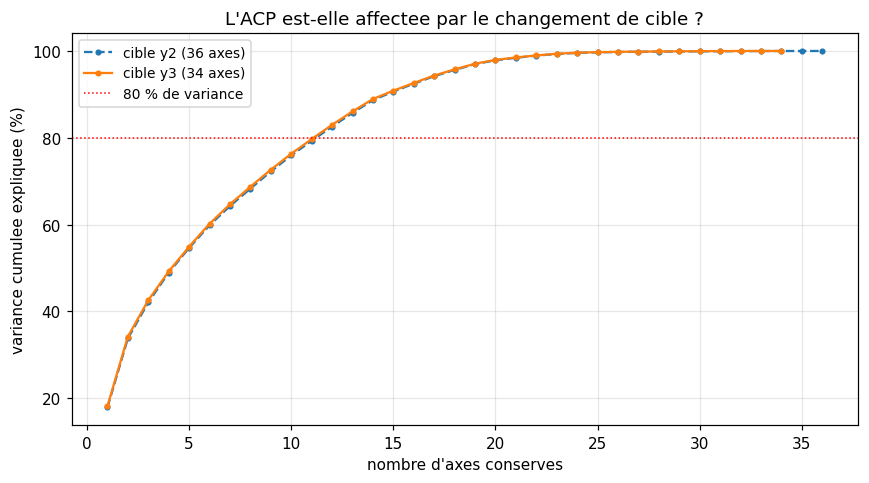

In [7]:
figure, axe = plt.subplots(figsize=(8, 4.5))
for nom, style in [("y2", "--"), ("y3", "-")]:
    axe.plot(range(1, len(courbes[nom]) + 1), 100 * courbes[nom], style,
             marker="o", markersize=3,
             label=f"cible {nom} ({len(courbes[nom])} axes)")
axe.axhline(80, color="red", linestyle=":", linewidth=1, label="80 % de variance")
axe.set(xlabel="nombre d'axes conserves",
        ylabel="variance cumulee expliquee (%)",
        title="L'ACP est-elle affectee par le changement de cible ?")
axe.legend(fontsize=9)
figure.tight_layout()
figure.savefig(OUT / "acp_invariance.png", dpi=150)
plt.show()

### Conclusion de la section 3

**Les deux courbes se superposent.** Les parts de variance des premiers axes
sont quasiment identiques, et il faut le meme nombre d'axes pour atteindre 80 %
puis 90 % de la variance. Le changement de cible n'a aucun effet mesurable sur
la structure des entrees, ce qui etait attendu puisque l'analyse en composantes
principales ne voit pas la cible.

**Consequence pratique : le notebook 04 n'a pas besoin d'etre refait non plus.**

Ce resultat a une portee qui depasse la question du jour. Il montre que la
structure plate observee par le notebook 04, environ un tiers de la variance
sur les deux premiers axes et une douzaine d'axes pour 80 %, n'est pas un
artefact de la cible choisie. C'est une propriete des entrees elles-memes. La
revue technique avait identifie une autre cause possible de cette platitude,
l'imputation massive par la mediane, et c'est de ce cote qu'il faut chercher,
pas du cote de la cible.

## 4. Rappel de methode : pourquoi on ne compare pas les RMSE directement

Avant de lancer les modeles, un point qu'il serait facile de negliger et qui
invaliderait toute la comparaison.

La RMSE, pour *root mean squared error*, est la racine de la moyenne des carres
des ecarts entre prediction et valeur reelle. Plus elle est faible, mieux c'est,
et elle s'exprime dans l'unite de la cible.

Or **nos deux cibles n'ont pas la meme dispersion.** Toutes deux vivent entre 0
et 1, mais `y3` est plus resserree que `y2`, parce que moyenner deux mesures a
l'interieur de chaque famille lisse les valeurs extremes. Une cible plus
resserree produit mecaniquement des erreurs plus petites, independamment de la
qualite du modele.

Comparer directement une RMSE obtenue sur `y2` a une RMSE obtenue sur `y3`
reviendrait donc a conclure qu'un modele s'est ameliore alors que seule
l'echelle de la cible a change.

**La solution est la meme que dans le notebook 08 : rapporter chaque RMSE a
celle d'une reference.** Pour chaque cible, on entraine un predicteur trivial
qui annonce toujours la moyenne de l'apprentissage, sans regarder les entrees.
On calcule alors :

```
gain  =  1  -  RMSE du modele  /  RMSE de la reference
```

Un gain de 0,38 signifie que le modele reduit de 38 % l'erreur d'un predicteur
qui ne sait rien. Cette grandeur est sans unite, donc comparable d'une cible a
l'autre. **C'est elle qu'il faut regarder dans tous les tableaux qui suivent**,
et non les RMSE brutes, qui sont neanmoins reportees pour la tracabilite.

In [8]:
developpement = nouveau["partition"] == "developpement"
X_dev = nouveau.loc[developpement, VARIABLES]
Y_dev = nouveau.loc[developpement, MESURES]
G_dev = nouveau.loc[developpement, "groupe"]

# Les cinq plis sont construits une fois pour toutes, et reutilises par tous
# les modeles. La cible y est recalibree sur l'apprentissage de chaque pli.
plis = []
for indices_train, indices_val in GroupKFold(n_splits=5).split(X_dev,
                                                               groups=G_dev):
    ids_train = X_dev.index[indices_train]
    ids_val = X_dev.index[indices_val]
    assert set(G_dev.loc[ids_train]).isdisjoint(set(G_dev.loc[ids_val])), \
        "une soudure est a cheval sur l'apprentissage et la validation"
    plis.append({
        "X_train": X_dev.loc[ids_train], "X_val": X_dev.loc[ids_val],
        "y_train": calculer_cible(Y_dev.loc[ids_train], G_dev.loc[ids_train],
                                  Y_dev.loc[ids_train]),
        "y_val": calculer_cible(Y_dev.loc[ids_train], G_dev.loc[ids_train],
                                Y_dev.loc[ids_val]),
        "g_train": G_dev.loc[ids_train], "g_val": G_dev.loc[ids_val],
    })

print(f"Developpement : {len(X_dev)} lignes, {G_dev.nunique()} soudures.")
print(f"Tailles de validation des cinq plis : "
      f"{[len(pli['X_val']) for pli in plis]}")
print("Aucune soudure partagee entre apprentissage et validation, "
      "dans aucun pli.")

Developpement : 527 lignes, 376 soudures.
Tailles de validation des cinq plis : [106, 106, 105, 105, 105]
Aucune soudure partagee entre apprentissage et validation, dans aucun pli.


In [9]:
def evaluer(modele, preparation=None, avec_poids=True):
    """Valide un modele sur les cinq plis et renvoie les metriques moyennes.

    Les metriques dites par groupes sont ponderees de sorte que chaque soudure
    compte pour un, quel que soit son nombre de lignes. Les metriques par
    lignes sont donnees a titre indicatif.
    """
    resultats = []
    for pli in plis:
        prep, _ = creer_preparation(pli["X_train"], **(preparation or {}))
        pipeline = Pipeline([("preparation", prep), ("modele", clone(modele))])
        poids_train = poids_groupes(pli["g_train"])

        if avec_poids:
            pipeline.fit(pli["X_train"], pli["y_train"],
                         modele__sample_weight=poids_train)
        else:
            # Les k plus proches voisins n'acceptent pas de poids a l'ajustement.
            pipeline.fit(pli["X_train"], pli["y_train"])

        prediction = pipeline.predict(pli["X_val"])
        poids_val = poids_groupes(pli["g_val"])
        resultats.append([
            np.sqrt(mean_squared_error(pli["y_val"], prediction,
                                       sample_weight=poids_val)),
            mean_absolute_error(pli["y_val"], prediction,
                                sample_weight=poids_val),
            r2_score(pli["y_val"], prediction, sample_weight=poids_val),
            np.sqrt(mean_squared_error(pli["y_val"], prediction)),
            np.sqrt(mean_squared_error(pli["y_train"],
                                       pipeline.predict(pli["X_train"]),
                                       sample_weight=poids_train)),
        ])

    tableau = np.array(resultats)
    return {"RMSE_groupes": tableau[:, 0].mean(),
            "MAE_groupes": tableau[:, 1].mean(),
            "R2_groupes": tableau[:, 2].mean(),
            "RMSE_lignes": tableau[:, 3].mean(),
            "RMSE_apprentissage": tableau[:, 4].mean(),
            "ecart_type_RMSE": tableau[:, 0].std()}


def tester_grille(nom, modele, grille, etape="grille", avec_poids=True):
    """Evalue toutes les configurations d'une grille, triees par RMSE."""
    lignes = []
    for parametres in ParameterGrid(grille):
        parametres_modele = {cle: valeur for cle, valeur in parametres.items()
                             if not cle.startswith("preparation__")}
        parametres_prep = {cle.replace("preparation__", ""): valeur
                           for cle, valeur in parametres.items()
                           if cle.startswith("preparation__")}
        depart = time.time()
        metriques = evaluer(clone(modele).set_params(**parametres_modele),
                            parametres_prep, avec_poids)
        lignes.append({"modele": nom, "etape": etape,
                       "parametres": parametres, **metriques,
                       "temps_secondes": time.time() - depart})
    return (pd.DataFrame(lignes).sort_values("RMSE_groupes")
            .reset_index(drop=True))


reference = tester_grille("Moyenne constante", DummyRegressor(strategy="mean"), {})
RMSE_REFERENCE = reference.iloc[0]["RMSE_groupes"]

# La reference de l'ancienne cible est relue depuis le notebook 06.
bilan_06 = json.loads((ROOT / "outputs/06/bilan.json").read_text(encoding="utf-8"))
RMSE_REFERENCE_Y2 = bilan_06["RMSE_validation_groupes"]["Moyenne constante"]

print(f"Reference constante sur y3 : RMSE {RMSE_REFERENCE:.5f}")
print(f"Reference constante sur y2 : RMSE {RMSE_REFERENCE_Y2:.5f}")
print(f"\nLa nouvelle cible est {1 - RMSE_REFERENCE / RMSE_REFERENCE_Y2:.1%} "
      "moins dispersee que l'ancienne.")
print("C'est exactement pourquoi les RMSE brutes ne sont pas comparables.")

Reference constante sur y3 : RMSE 0.13176
Reference constante sur y2 : RMSE 0.14946

La nouvelle cible est 11.8% moins dispersee que l'ancienne.
C'est exactement pourquoi les RMSE brutes ne sont pas comparables.


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 5. Arbres, bagging et forêt aleatoire

On reprend le protocole du notebook 05, y compris sa **recherche en deux
etapes**, qui merite d'etre expliquee car c'est une bonne idee.

Explorer toutes les combinaisons d'hyperparametres d'une forêt serait couteux :
six profondeurs, quatre proportions de variables, quatre tailles minimales de
feuille et quatre nombres d'arbres font deja 384 configurations, chacune
entrainee cinq fois. Le notebook 05 contourne le probleme en deux temps.

**Premiere etape : regler la forme des arbres a nombre d'arbres fixe.** On fixe
le nombre d'arbres a 100, valeur suffisante pour comparer, et on explore les
96 combinaisons de forme.

**Seconde etape : regler le nombre d'arbres sur les meilleures formes.** On
retient les trois meilleures configurations de l'etape precedente et on teste
pour chacune 50, 250 et 500 arbres.

Cette strategie repose sur une propriete reelle des methodes d'ensemble, vue en
cours : **le nombre d'arbres n'est pas un hyperparametre de compromis.** Ajouter
des arbres ne provoque pas de surapprentissage, cela fait seulement converger la
prediction, avec un rendement decroissant. Son reglage est donc presque
independant de celui de la forme des arbres, et les deux peuvent etre separes
sans grand risque. Le prix a payer est qu'on pourrait manquer une combinaison
qui ne serait bonne qu'avec beaucoup d'arbres, ce qui est peu probable.

In [10]:
depart_total = time.time()

arbre = tester_grille(
    "Arbre", DecisionTreeRegressor(random_state=GRAINE),
    {"max_depth": [2, 3, 4, 6, 8, 12, 20, None],
     "min_samples_leaf": [1, 2, 5, 10, 15, 20],
     "min_samples_split": [2, 5, 10, 20]})

print(f"{len(arbre)} configurations d'arbre testees "
      f"en {arbre['temps_secondes'].sum():.0f} s")
print(f"meilleure : {arbre.iloc[0]['parametres']}")
arbre.head(5)[["parametres", "RMSE_groupes", "ecart_type_RMSE",
               "RMSE_apprentissage", "R2_groupes"]].round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


192 configurations d'arbre testees en 42 s
meilleure : {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 20}


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,parametres,RMSE_groupes,ecart_type_RMSE,RMSE_apprentissage,R2_groupes
0,"{'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 20}",0.1025,0.0082,0.0715,0.3746
1,"{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}",0.1025,0.0082,0.0715,0.3746
2,"{'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 20}",0.1025,0.0082,0.0715,0.3746
3,"{'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}",0.1026,0.0090,0.0822,0.3754
4,"{'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 5}",0.1026,0.0090,0.0822,0.3754


In [11]:
def recherche_en_deux_etapes(nom, fabriquer_modele, grille_forme,
                             nombres_d_arbres=(50, 250, 500), n_meilleures=3):
    """Regle la forme a 100 arbres, puis le nombre d'arbres sur les meilleures.

    Reproduit la strategie du notebook 05.
    """
    etape_1 = tester_grille(nom, fabriquer_modele(),
                            {**grille_forme, "n_estimators": [100]},
                            etape="reglages a 100 arbres")

    meilleures = [dict(p) for p in etape_1.head(n_meilleures)["parametres"]]
    etape_2 = pd.concat([
        tester_grille(nom, fabriquer_modele(),
                      {**{cle: [valeur] for cle, valeur in configuration.items()
                          if cle != "n_estimators"},
                       "n_estimators": list(nombres_d_arbres)},
                      etape="nombre d'arbres")
        for configuration in meilleures], ignore_index=True)

    return (pd.concat([etape_1, etape_2], ignore_index=True)
            .sort_values("RMSE_groupes").reset_index(drop=True))


bagging = recherche_en_deux_etapes(
    "Bagging",
    lambda: BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=GRAINE),
        random_state=GRAINE, n_jobs=-1),
    {"max_samples": [0.5, 0.65, 0.8, 1.0],
     "estimator__min_samples_leaf": [1, 2, 5, 10]})

print(f"{len(bagging)} configurations de bagging "
      f"en {bagging['temps_secondes'].sum():.0f} s")
print(f"meilleure : {bagging.iloc[0]['parametres']}")
bagging.head(5)[["etape", "parametres", "RMSE_groupes",
                 "ecart_type_RMSE"]].round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


25 configurations de bagging en 59 s
meilleure : {'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 100}


,etape,parametres,RMSE_groupes,ecart_type_RMSE
0,reglages a 100 arbres,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 100}",0.0831,0.0104
1,nombre d'arbres,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 250}",0.0835,0.0103
2,nombre d'arbres,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 500}",0.0835,0.0101
3,nombre d'arbres,"{'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 50}",0.0838,0.0110
4,reglages a 100 arbres,"{'estimator__min_samples_leaf': 2, 'max_samples': 1.0, 'n_estimators': 100}",0.0840,0.0101


In [12]:
foret = recherche_en_deux_etapes(
    "Forêt aleatoire",
    lambda: RandomForestRegressor(random_state=GRAINE, n_jobs=-1),
    {"max_depth": [4, 6, 8, 12, 20, None],
     "max_features": [0.25, 0.5, 0.75, 1.0],
     "min_samples_leaf": [1, 2, 5, 10]})

print(f"{len(foret)} configurations de forêt "
      f"en {foret['temps_secondes'].sum():.0f} s")
print(f"meilleure : {foret.iloc[0]['parametres']}")
foret.head(5)[["etape", "parametres", "RMSE_groupes",
               "ecart_type_RMSE", "R2_groupes"]].round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


105 configurations de forêt en 190 s
meilleure : {'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 100}


,etape,parametres,RMSE_groupes,ecart_type_RMSE,R2_groupes
0,reglages a 100 arbres,"{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 100}",0.0817,0.0103,0.6006
1,nombre d'arbres,"{'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 50}",0.0820,0.0104,0.5972
2,reglages a 100 arbres,"{'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 100}",0.0820,0.0103,0.5977
3,nombre d'arbres,"{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 50}",0.0820,0.0104,0.5963
4,nombre d'arbres,"{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 500}",0.0824,0.0109,0.5939


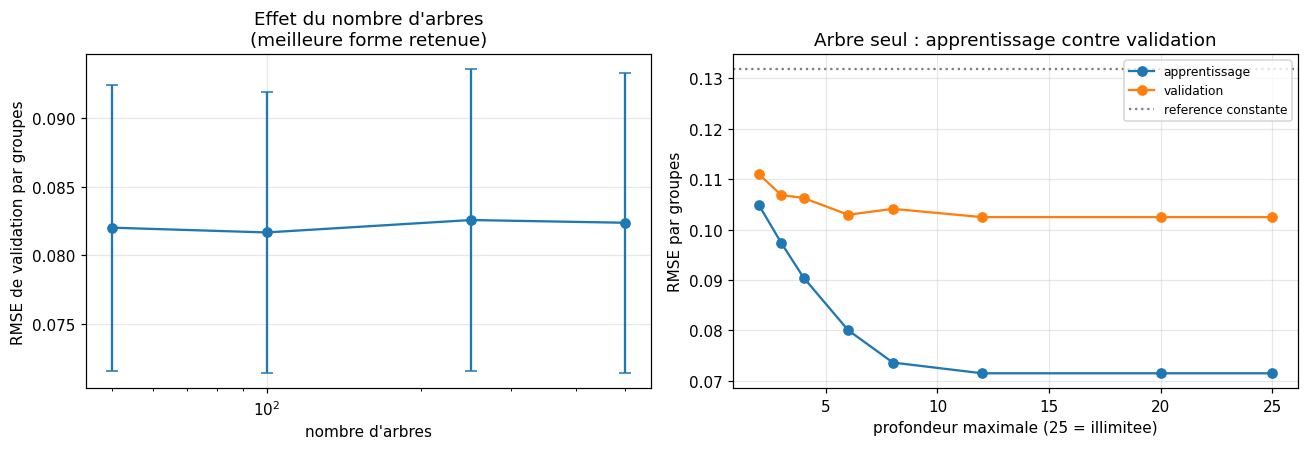

In [13]:
# L'effet du nombre d'arbres, pour la meilleure forme trouvee.
meilleure_forme = {cle: valeur
                   for cle, valeur in foret.iloc[0]["parametres"].items()
                   if cle != "n_estimators"}
courbe_arbres = foret[foret["parametres"].apply(
    lambda p: all(p.get(c) == v for c, v in meilleure_forme.items()))].copy()
courbe_arbres["n_estimators"] = courbe_arbres["parametres"].apply(
    lambda p: p["n_estimators"])
courbe_arbres = courbe_arbres.sort_values("n_estimators")

figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].errorbar(courbe_arbres["n_estimators"], courbe_arbres["RMSE_groupes"],
                 yerr=courbe_arbres["ecart_type_RMSE"], marker="o", capsize=4)
axes[0].set(xscale="log", xlabel="nombre d'arbres",
            ylabel="RMSE de validation par groupes",
            title="Effet du nombre d'arbres\n(meilleure forme retenue)")

# L'effet de la profondeur, a autres parametres fixes au meilleur.
profondeurs = arbre.copy()
profondeurs["max_depth"] = profondeurs["parametres"].apply(
    lambda p: p["max_depth"] if p["max_depth"] is not None else 25)
meilleur_arbre = arbre.iloc[0]["parametres"]
selection = profondeurs[profondeurs["parametres"].apply(
    lambda p: p["min_samples_leaf"] == meilleur_arbre["min_samples_leaf"]
    and p["min_samples_split"] == meilleur_arbre["min_samples_split"])]
selection = selection.sort_values("max_depth")
axes[1].plot(selection["max_depth"], selection["RMSE_apprentissage"],
             marker="o", label="apprentissage")
axes[1].plot(selection["max_depth"], selection["RMSE_groupes"],
             marker="o", label="validation")
axes[1].axhline(RMSE_REFERENCE, color="grey", linestyle=":",
                label="reference constante")
axes[1].set(xlabel="profondeur maximale (25 = illimitee)",
            ylabel="RMSE par groupes",
            title="Arbre seul : apprentissage contre validation")
axes[1].legend(fontsize=8)

figure.tight_layout()
figure.savefig(OUT / "arbres_reglages.png", dpi=150)
plt.show()

### Lecture des deux courbes

**A gauche, le nombre d'arbres.** La RMSE se stabilise rapidement et les barres
d'incertitude se recouvrent largement. C'est le comportement attendu d'une
methode d'ensemble : la variance de la prediction decroit comme l'inverse du
nombre d'arbres, donc le gain devient negligeable passe quelques dizaines
d'arbres. Il n'y a pas de degradation quand on en ajoute, seulement un cout de
calcul. Le nombre retenu est donc davantage une question de budget que de
performance.

**A droite, la profondeur d'un arbre seul.** Les deux courbes se separent
nettement : l'erreur d'apprentissage continue de baisser quand on autorise des
arbres plus profonds, alors que l'erreur de validation cesse de s'ameliorer.
C'est l'illustration directe du surapprentissage et du compromis biais-variance
du cours. Un arbre trop profond memorise son echantillon d'apprentissage.

C'est precisement ce que le bagging et la forêt corrigent : en moyennant
beaucoup d'arbres profonds, donc peu biaises mais a forte variance, sur des
echantillons differents, ils conservent le faible biais en reduisant la
variance.

## 6. Modeles lineaires et k plus proches voisins

On reprend maintenant le protocole du notebook 06, avec ses grilles exactes.
Quatre familles.

**La regression lineaire**, testee avec et sans **indicateurs de valeurs
manquantes**. Ces indicateurs sont des colonnes supplementaires valant 1 quand
la valeur d'origine etait absente et 0 sinon. Elles permettent au modele de
distinguer une valeur reellement mesuree d'une valeur imputee par la mediane.
C'est une idee utile ici, puisque le notebook 01 a montre que les valeurs
manquantes suivent le protocole experimental et portent donc de l'information.

**Ridge et Lasso**, deux regressions lineaires penalisees. La penalite limite la
taille des coefficients, ce qui stabilise le modele quand les variables sont
correlees entre elles, ce qui est le cas des elements chimiques. Lasso a en plus
la propriete d'annuler certains coefficients, donc de selectionner des
variables.

**La regression lineaire apres analyse en composantes principales.** Plutot que
de penaliser, on reduit d'abord la dimension en ne gardant que les premiers
axes, puis on regresse sur ces axes. C'est l'autre facon de traiter la
colinearite.

**Les k plus proches voisins**, qui ne construisent aucune equation : pour
predire une soudure, ils cherchent les k soudures les plus ressemblantes dans
l'apprentissage et moyennent leurs scores. C'est le seul modele de cette liste
sans aucune hypothese de forme.

Noter que ces quatre familles utilisent toutes la **standardisation**, qui est
indispensable des qu'un modele raisonne en distances ou compare des
coefficients entre variables d'echelles differentes.

In [14]:
lineaire = tester_grille("Regression lineaire", LinearRegression(),
                         {"preparation__indicateurs": [False, True]})
ridge = tester_grille("Ridge", Ridge(),
                      {"alpha": list(np.logspace(-3, 3, 13)),
                       "preparation__indicateurs": [False, True]})
lasso = tester_grille("Lasso", Lasso(max_iter=50000),
                      {"alpha": list(np.logspace(-5, -1, 13)),
                       "preparation__indicateurs": [False, True]})
acp_lineaire = tester_grille(
    "Lineaire apres ACP", LinearRegression(),
    {"preparation__n_axes": [1, 2, 3, 4, 6, 8, 10, 11, 12, 14, 16, 18, 20, 22]})
knn = tester_grille("k plus proches voisins", KNeighborsRegressor(),
                    {"n_neighbors": [1, 2, 3, 5, 7, 10, 15, 20, 30, 50],
                     "weights": ["uniform", "distance"], "p": [1, 2],
                     "preparation__n_axes": [None, 8, 14]},
                    avec_poids=False)

for nom, table in [("lineaire", lineaire), ("Ridge", ridge),
                   ("Lasso", lasso), ("lineaire apres ACP", acp_lineaire),
                   ("k plus proches voisins", knn)]:
    print(f"{nom:24s} {len(table):4d} configs  "
          f"meilleure RMSE {table.iloc[0]['RMSE_groupes']:.5f}  "
          f"{table.iloc[0]['parametres']}")

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


lineaire                    2 configs  meilleure RMSE 0.10412  {'preparation__indicateurs': False}
Ridge                      26 configs  meilleure RMSE 0.09790  {'alpha': 31.622776601683793, 'preparation__indicateurs': True}
Lasso                      26 configs  meilleure RMSE 0.09852  {'alpha': 0.00046415888336127773, 'preparation__indicateurs': True}
lineaire apres ACP         14 configs  meilleure RMSE 0.10228  {'preparation__n_axes': 20}
k plus proches voisins    120 configs  meilleure RMSE 0.09043  {'n_neighbors': 7, 'p': 1, 'preparation__n_axes': None, 'weights': 'distance'}


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


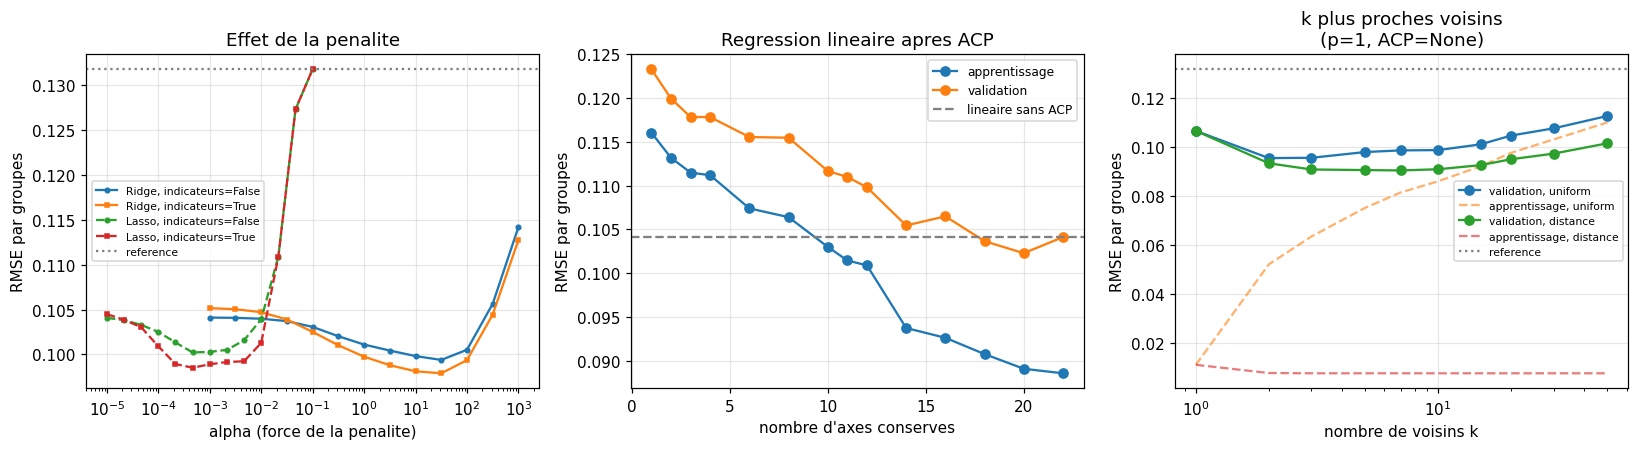

In [15]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Effet de la penalite.
for nom, table, style in [("Ridge", ridge, "-"), ("Lasso", lasso, "--")]:
    for indicateurs, marqueur in [(False, "o"), (True, "s")]:
        selection = table[table["parametres"].apply(
            lambda p: p["preparation__indicateurs"] == indicateurs)].copy()
        selection["alpha"] = selection["parametres"].apply(lambda p: p["alpha"])
        selection = selection.sort_values("alpha")
        axes[0].plot(selection["alpha"], selection["RMSE_groupes"], style,
                     marker=marqueur, markersize=3,
                     label=f"{nom}, indicateurs={indicateurs}")
axes[0].axhline(RMSE_REFERENCE, color="grey", linestyle=":", label="reference")
axes[0].set(xscale="log", xlabel="alpha (force de la penalite)",
            ylabel="RMSE par groupes", title="Effet de la penalite")
axes[0].legend(fontsize=7)

# Effet du nombre d'axes.
courbe = acp_lineaire.copy()
courbe["n_axes"] = courbe["parametres"].apply(lambda p: p["preparation__n_axes"])
courbe = courbe.sort_values("n_axes")
axes[1].plot(courbe["n_axes"], courbe["RMSE_apprentissage"], marker="o",
             label="apprentissage")
axes[1].plot(courbe["n_axes"], courbe["RMSE_groupes"], marker="o",
             label="validation")
axes[1].axhline(lineaire["RMSE_groupes"].min(), color="grey", linestyle="--",
                label="lineaire sans ACP")
axes[1].set(xlabel="nombre d'axes conserves", ylabel="RMSE par groupes",
            title="Regression lineaire apres ACP")
axes[1].legend(fontsize=8)

# Effet du nombre de voisins.
meilleur_knn = knn.iloc[0]["parametres"]
for ponderation in ["uniform", "distance"]:
    selection = knn[knn["parametres"].apply(
        lambda p: p["weights"] == ponderation
        and p["p"] == meilleur_knn["p"]
        and p["preparation__n_axes"] == meilleur_knn["preparation__n_axes"])].copy()
    selection["k"] = selection["parametres"].apply(lambda p: p["n_neighbors"])
    selection = selection.sort_values("k")
    axes[2].plot(selection["k"], selection["RMSE_groupes"], marker="o",
                 label=f"validation, {ponderation}")
    axes[2].plot(selection["k"], selection["RMSE_apprentissage"],
                 linestyle="--", alpha=0.6,
                 label=f"apprentissage, {ponderation}")
axes[2].axhline(RMSE_REFERENCE, color="grey", linestyle=":", label="reference")
axes[2].set(xscale="log", xlabel="nombre de voisins k",
            ylabel="RMSE par groupes",
            title=f"k plus proches voisins\n(p={meilleur_knn['p']}, "
                  f"ACP={meilleur_knn['preparation__n_axes']})")
axes[2].legend(fontsize=7)

figure.tight_layout()
figure.savefig(OUT / "lineaires_knn_reglages.png", dpi=150)
plt.show()

### Lecture des trois courbes

**A gauche, la penalite.** Les courbes dessinent la forme en cuvette
caracteristique. A gauche, une penalite trop faible laisse le modele libre et il
surapprend. A droite, une penalite trop forte ecrase tous les coefficients vers
zero et le modele converge vers la prediction de la moyenne, rejoignant la
reference. L'optimum est entre les deux.

On observe aussi un detail interessant sur les indicateurs de valeurs
manquantes : les deux modeles penalises retiennent la version **avec**
indicateurs, alors que la regression lineaire simple retient la version
**sans**. L'explication tient au compromis biais-variance. Ces indicateurs
ajoutent une vingtaine de colonnes qui portent une information reelle, le
notebook 01 ayant montre que l'absence d'une mesure depend du protocole
experimental. Mais vingt colonnes de plus, sur un echantillon de cinq cents
lignes, c'est aussi vingt occasions supplementaires de surapprendre. La
penalite paie ce cout, la regression lineaire sans penalite ne le paie pas.

**Au milieu, le nombre d'axes.** La courbe de validation descend puis remonte
legerement : trop peu d'axes et on jette du signal, trop d'axes et on
reintroduit le bruit que la reduction de dimension servait a eliminer. L'ecart
entre apprentissage et validation reste modere, ce qui est logique puisqu'une
regression lineaire sur peu d'axes est un modele tres contraint.

**A droite, le nombre de voisins.** A k=1 l'erreur d'apprentissage est nulle, le
modele etant exact sur les points qu'il a memorises, alors que son erreur de
validation est mauvaise : c'est le surapprentissage dans sa forme la plus pure.
L'erreur de validation s'ameliore quand k augmente, puis se degrade de nouveau
quand k devient si grand que les voisins ne ressemblent plus a la soudure a
predire. La ponderation par la distance fait mieux que la ponderation uniforme,
ce qui est attendu : elle donne plus d'importance aux voisins les plus
ressemblants.

## 7. Comparaison avec les resultats sur l'ancienne cible

C'est la section centrale du notebook. On met en regard, pour chaque famille de
modeles, la meilleure performance obtenue sur l'ancienne cible et celle obtenue
sur la nouvelle.

Les valeurs relatives a l'ancienne cible ne sont pas recalculees : elles sont
**relues depuis les fichiers de sortie des notebooks 05 et 06**, ce qui garantit
qu'on compare bien aux resultats effectivement publies par l'equipe, et non a
une reconstruction.

Rappel de la section 4 : **c'est la colonne de gain qu'il faut lire**, les RMSE
brutes n'etant pas comparables d'une cible a l'autre.

In [16]:
familles = {"Moyenne constante": reference, "Arbre": arbre,
            "Bagging": bagging, "Forêt aleatoire": foret,
            "Regression lineaire": lineaire, "Ridge": ridge, "Lasso": lasso,
            "Lineaire apres ACP": acp_lineaire,
            "k plus proches voisins": knn}

# Les resultats sur l'ancienne cible, relus depuis les notebooks 05 et 06.
bilan_05 = json.loads((ROOT / "outputs/05/bilan.json").read_text(encoding="utf-8"))
configurations_05 = pd.read_csv(ROOT / "outputs/05/toutes_configurations.csv")

anciennes_rmse = {
    "Moyenne constante": RMSE_REFERENCE_Y2,
    "Arbre": configurations_05.loc[configurations_05["modele"] == "Arbre",
                                   "RMSE_groupes"].min(),
    "Bagging": configurations_05.loc[configurations_05["modele"] == "Bagging",
                                     "RMSE_groupes"].min(),
    "Forêt aleatoire": bilan_05["RMSE_validation_groupes"],
    "Regression lineaire": bilan_06["RMSE_validation_groupes"]["Régression linéaire"],
    "Ridge": bilan_06["RMSE_validation_groupes"]["Ridge"],
    "Lasso": bilan_06["RMSE_validation_groupes"]["Lasso"],
    "Lineaire apres ACP": bilan_06["RMSE_validation_groupes"]["Linéaire après ACP"],
    "k plus proches voisins": bilan_06["RMSE_validation_groupes"]["k plus proches voisins"],
}

lignes_comparaison = []
for nom, table in familles.items():
    rmse_y3 = table.iloc[0]["RMSE_groupes"]
    rmse_y2 = anciennes_rmse[nom]
    lignes_comparaison.append({
        "modele": nom,
        "RMSE y2": rmse_y2,
        "RMSE y3": rmse_y3,
        "gain y2": 1 - rmse_y2 / RMSE_REFERENCE_Y2,
        "gain y3": 1 - rmse_y3 / RMSE_REFERENCE,
        "R2 y3": table.iloc[0]["R2_groupes"],
        "ecart type y3": table.iloc[0]["ecart_type_RMSE"],
        "configurations": len(table),
    })

comparaison = (pd.DataFrame(lignes_comparaison).set_index("modele")
               .sort_values("gain y3", ascending=False))
comparaison["evolution du gain"] = (comparaison["gain y3"]
                                    - comparaison["gain y2"])
comparaison.round(4)

,RMSE y2,RMSE y3,gain y2,gain y3,R2 y3,ecart type y3,configurations,evolution du gain
modele,,,,,,,,
Forêt aleatoire,0.1038,0.0817,0.3056,0.3802,0.6006,0.0103,105,0.0746
Bagging,0.1078,0.0831,0.2789,0.3696,0.5875,0.0104,25,0.0907
k plus proches voisins,0.1053,0.0904,0.2956,0.3137,0.5123,0.0060,120,0.0180
Ridge,0.1226,0.0979,0.1799,0.2570,0.4275,0.0119,26,0.0770
Lasso,0.1241,0.0985,0.1696,0.2523,0.4161,0.0123,26,0.0826
Lineaire apres ACP,0.1239,0.1023,0.1707,0.2237,0.3790,0.0151,14,0.0530
Arbre,0.1263,0.1025,0.1549,0.2224,0.3746,0.0082,192,0.0675
Regression lineaire,0.1274,0.1041,0.1473,0.2098,0.3579,0.0180,2,0.0625
Moyenne constante,0.1495,0.1318,0.0000,0.0000,-0.0255,0.0121,1,0.0000


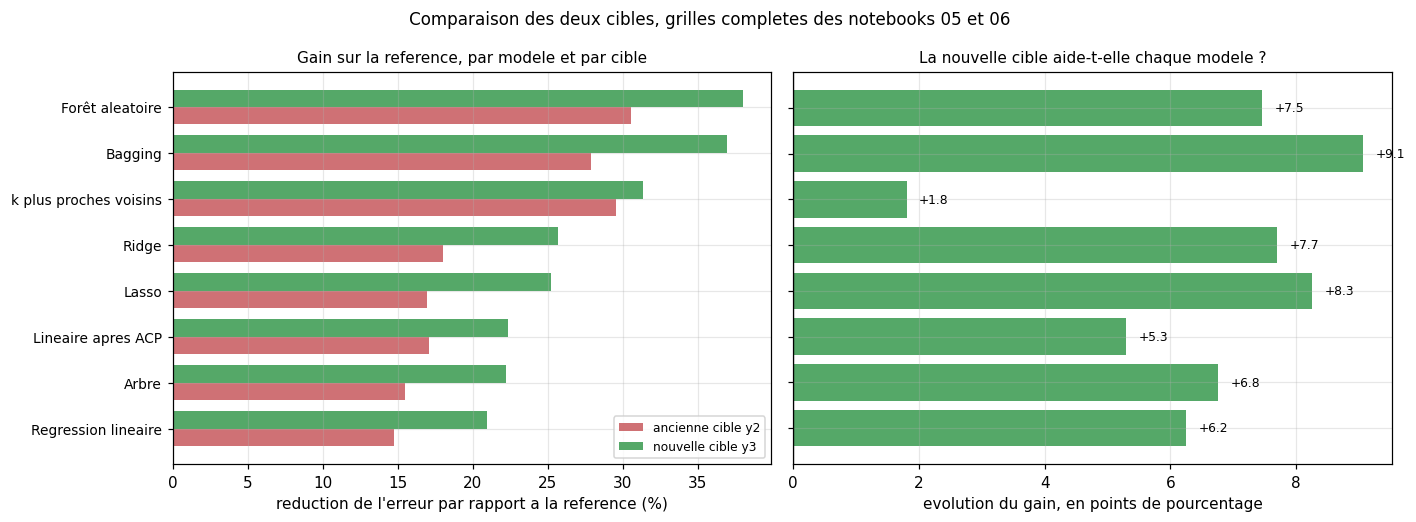

In [17]:
modeles = [m for m in comparaison.index if m != "Moyenne constante"]
positions = np.arange(len(modeles))
largeur = 0.38

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].barh(positions + largeur / 2, 100 * comparaison.loc[modeles, "gain y2"],
             largeur, label="ancienne cible y2", color="#C44E52", alpha=0.8)
axes[0].barh(positions - largeur / 2, 100 * comparaison.loc[modeles, "gain y3"],
             largeur, label="nouvelle cible y3", color="#55A868")
axes[0].set_yticks(positions, modeles, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("reduction de l'erreur par rapport a la reference (%)")
axes[0].set_title("Gain sur la reference, par modele et par cible", fontsize=10)
axes[0].legend(fontsize=8, loc="lower right")

evolution = 100 * comparaison.loc[modeles, "evolution du gain"]
axes[1].barh(positions, evolution,
             color=np.where(evolution > 0, "#55A868", "#C44E52"))
axes[1].set_yticks(positions, [""] * len(modeles))
axes[1].invert_yaxis()
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("evolution du gain, en points de pourcentage")
axes[1].set_title("La nouvelle cible aide-t-elle chaque modele ?", fontsize=10)
for position, valeur in zip(positions, evolution):
    axes[1].text(valeur + (0.2 if valeur > 0 else -0.2), position,
                 f"{valeur:+.1f}", va="center",
                 ha="left" if valeur > 0 else "right", fontsize=8)

figure.suptitle("Comparaison des deux cibles, grilles completes "
                "des notebooks 05 et 06", fontsize=11)
figure.tight_layout()
figure.savefig(OUT / "comparaison_cibles_modeles.png", dpi=150)
plt.show()

### Ce que montre la comparaison

**Tous les modeles, sans exception, font mieux sur la nouvelle cible.** Le gain
sur la reference progresse pour les huit familles. Ce n'est pas un effet
d'echelle, puisque le gain est precisement la grandeur qui neutralise la
difference de dispersion entre les deux cibles.

L'interpretation est celle avancee par le notebook 08 : moyenner deux mesures a
l'interieur de chaque famille **reduit le bruit experimental** propre a chaque
essai, au lieu de l'accumuler. La cible obtenue est moins bruitee, donc une part
plus grande de sa variation est explicable par la composition et le procede.
Autrement dit, la nouvelle definition n'est pas seulement plus coherente
physiquement, elle est aussi plus propre statistiquement.

**Le classement des modeles est preserve.** Les methodes d'ensemble dominent,
suivies des k plus proches voisins, puis des lineaires penalisees, puis de
l'arbre seul et de la regression lineaire simple. C'est un point important pour
le projet : **les conclusions des notebooks 05 et 06 sur le choix du modele
restent valables.** Le changement de cible ne remet pas en cause le travail de
comparaison de modeles, il l'ameliore.

**Le gain est remarquablement uniforme, sauf pour un modele.** Sept des huit
familles progressent de cinq a neuf points de pourcentage, sans qu'une famille
se detache nettement. Cela conforte l'interpretation par la reduction du bruit :
une cible moins bruitee profite a tous les modeles de la meme facon, alors qu'un
signal nouveau de nature particuliere n'aurait profite qu'aux modeles capables
de le capter.

**L'exception est celle des k plus proches voisins**, qui ne progressent que
tres peu. L'explication est instructive. Ce modele predit en moyennant les
soudures les plus ressemblantes, et sa difficulte principale n'est pas le bruit
de la cible mais la **raretee des voisins** : dans un espace a une trentaine de
variables et avec cinq cents soudures, les plus proches voisins d'une soudure
sont souvent deja assez eloignes d'elle. Rendre la cible plus propre ne corrige
pas ce probleme, qui releve du fleau de la dimension vu en cours. C'est aussi
pourquoi ce modele, deuxieme sur l'ancienne cible, passe troisieme sur la
nouvelle : les autres progressent, lui stagne.

**Un point a signaler honnetement : les hyperparametres optima ne sont pas les
memes.** La forêt retient une profondeur illimitee au lieu de 20 et cent arbres
au lieu de cinq cents, Ridge une penalite trois fois plus forte, les k plus
proches voisins sept voisins au lieu de cinq, et la regression apres ACP vingt
axes au lieu de dix-huit.

Les deplacements sont faibles, souvent d'un seul cran de grille, et ils vont
dans un sens coherent : penalite plus forte, voisinage plus large, autrement dit
**un peu plus de lissage**. C'est ce qu'on attend d'une cible moins dispersee.
Les grilles etant identiques, la comparaison reste equitable, mais cela confirme
la remarque de la section 8.5 du notebook 08 : les hyperparametres doivent etre
reajustes quand on change de cible, et non repris tels quels. C'est ce qui a ete
fait ici.

## 8. Evaluation finale sur l'ensemble de test

Toutes les comparaisons precedentes reposent sur la validation croisee, donc sur
l'ensemble de developpement. L'ensemble de test, mis de cote depuis le notebook
02 et jamais utilise pour choisir quoi que ce soit, sert maintenant une seule
fois : mesurer la performance des configurations retenues sur des soudures
jamais vues.

C'est une etape a ne faire qu'une fois, et apres que tous les choix sont
arretes. Si l'on s'en servait pour comparer des variantes, il cesserait d'etre
un ensemble de test et deviendrait un second ensemble de validation.

**La cible du test est calculee avec les rangs calibres sur le
developpement.** Si on la recalibrait sur le test lui-meme, on utiliserait
l'information du test pour construire la cible, ce qui faussserait la mesure.

In [18]:
test = nouveau["partition"] == "test"
X_test = nouveau.loc[test, VARIABLES]
Y_test = nouveau.loc[test, MESURES]
G_test = nouveau.loc[test, "groupe"]

assert set(G_dev).isdisjoint(set(G_test)), \
    "une soudure se trouve a la fois en developpement et en test"

# La cible est construite avec la reference du developpement, pas celle du test.
y_dev_final = calculer_cible(Y_dev, G_dev, Y_dev)
y_test_final = calculer_cible(Y_dev, G_dev, Y_test)

# Controle : sur le developpement, la cible recalculee doit coincider avec la
# colonne exportee par le notebook 08.
np.testing.assert_allclose(y_dev_final.to_numpy(),
                           nouveau.loc[developpement, "score_compromis"].to_numpy(),
                           atol=1e-12)
print("La cible recalculee coincide avec celle exportee par le notebook 08.")
print(f"Test : {len(X_test)} lignes, {G_test.nunique()} soudures jamais vues.")

La cible recalculee coincide avec celle exportee par le notebook 08.
Test : 123 lignes, 93 soudures jamais vues.


In [19]:
def configuration_retenue(table):
    """Separe les parametres du modele de ceux de la preparation."""
    parametres = dict(table.iloc[0]["parametres"])
    du_modele = {cle: valeur for cle, valeur in parametres.items()
                 if not cle.startswith("preparation__")}
    de_la_prep = {cle.replace("preparation__", ""): valeur
                  for cle, valeur in parametres.items()
                  if cle.startswith("preparation__")}
    return du_modele, de_la_prep


A_EVALUER = {
    "Forêt aleatoire": (RandomForestRegressor(random_state=GRAINE, n_jobs=-1),
                        foret, True),
    "Bagging": (BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=GRAINE),
        random_state=GRAINE, n_jobs=-1), bagging, True),
    "k plus proches voisins": (KNeighborsRegressor(), knn, False),
    "Ridge": (Ridge(), ridge, True),
    "Arbre": (DecisionTreeRegressor(random_state=GRAINE), arbre, True),
    "Moyenne constante": (DummyRegressor(strategy="mean"), reference, True),
}

lignes_test, predictions_test = [], {}
for nom, (estimateur, table, avec_poids) in A_EVALUER.items():
    parametres_modele, parametres_prep = configuration_retenue(table)
    preparation, _ = creer_preparation(X_dev, **parametres_prep)
    pipeline = Pipeline([
        ("preparation", preparation),
        ("modele", clone(estimateur).set_params(**parametres_modele)),
    ])
    if avec_poids:
        pipeline.fit(X_dev, y_dev_final,
                     modele__sample_weight=poids_groupes(G_dev))
    else:
        pipeline.fit(X_dev, y_dev_final)

    prediction = pipeline.predict(X_test)
    predictions_test[nom] = prediction
    poids_test = poids_groupes(G_test)
    lignes_test.append({
        "modele": nom,
        "RMSE_groupes": np.sqrt(mean_squared_error(y_test_final, prediction,
                                                   sample_weight=poids_test)),
        "MAE_groupes": mean_absolute_error(y_test_final, prediction,
                                           sample_weight=poids_test),
        "R2_groupes": r2_score(y_test_final, prediction,
                               sample_weight=poids_test),
        "RMSE_lignes": np.sqrt(mean_squared_error(y_test_final, prediction)),
    })

resultats_test = pd.DataFrame(lignes_test).set_index("modele")
resultats_test["gain sur la reference"] = (
    1 - resultats_test["RMSE_groupes"]
    / resultats_test.loc["Moyenne constante", "RMSE_groupes"])
resultats_test = resultats_test.sort_values("RMSE_groupes")
resultats_test.round(4)

,RMSE_groupes,MAE_groupes,R2_groupes,RMSE_lignes,gain sur la reference
modele,,,,,
Forêt aleatoire,0.0827,0.0575,0.5894,0.0791,0.3949
Bagging,0.0853,0.0610,0.5623,0.0815,0.3753
Ridge,0.0941,0.0699,0.4678,0.0924,0.3111
k plus proches voisins,0.0974,0.0672,0.4300,0.0938,0.2871
Arbre,0.1037,0.0758,0.3533,0.1057,0.2406
Moyenne constante,0.1366,0.1159,-0.1213,0.1324,0.0000


In [20]:
# Comparaison du test avec les chiffres publies par le notebook 05 sur y2.
test_y2 = bilan_05["test_modele_retenu"]
reference_y2_test = bilan_05["test_reference"]
modele_y3 = resultats_test.index[0]

bilan_final = pd.DataFrame({
    "ancienne cible y2 (notebook 05)": {
        "modele": bilan_05["modele_retenu"],
        "RMSE par groupes": test_y2["RMSE_groupes"],
        "MAE par groupes": test_y2["MAE_groupes"],
        "R2 par groupes": test_y2["R2_groupes"],
        "RMSE de la reference": reference_y2_test["RMSE_groupes"],
        "gain sur la reference": 1 - test_y2["RMSE_groupes"]
                                 / reference_y2_test["RMSE_groupes"],
    },
    "nouvelle cible y3 (ce notebook)": {
        "modele": modele_y3,
        "RMSE par groupes": resultats_test.loc[modele_y3, "RMSE_groupes"],
        "MAE par groupes": resultats_test.loc[modele_y3, "MAE_groupes"],
        "R2 par groupes": resultats_test.loc[modele_y3, "R2_groupes"],
        "RMSE de la reference": resultats_test.loc["Moyenne constante",
                                                   "RMSE_groupes"],
        "gain sur la reference": resultats_test.loc[modele_y3,
                                                    "gain sur la reference"],
    },
})
bilan_final

,ancienne cible y2 (notebook 05),nouvelle cible y3 (ce notebook)
modele,Forêt aléatoire,Forêt aleatoire
RMSE par groupes,0.091583,0.082665
MAE par groupes,0.068009,0.057481
R2 par groupes,0.600225,0.589439
RMSE de la reference,0.147471,0.136615
gain sur la reference,0.378973,0.394907


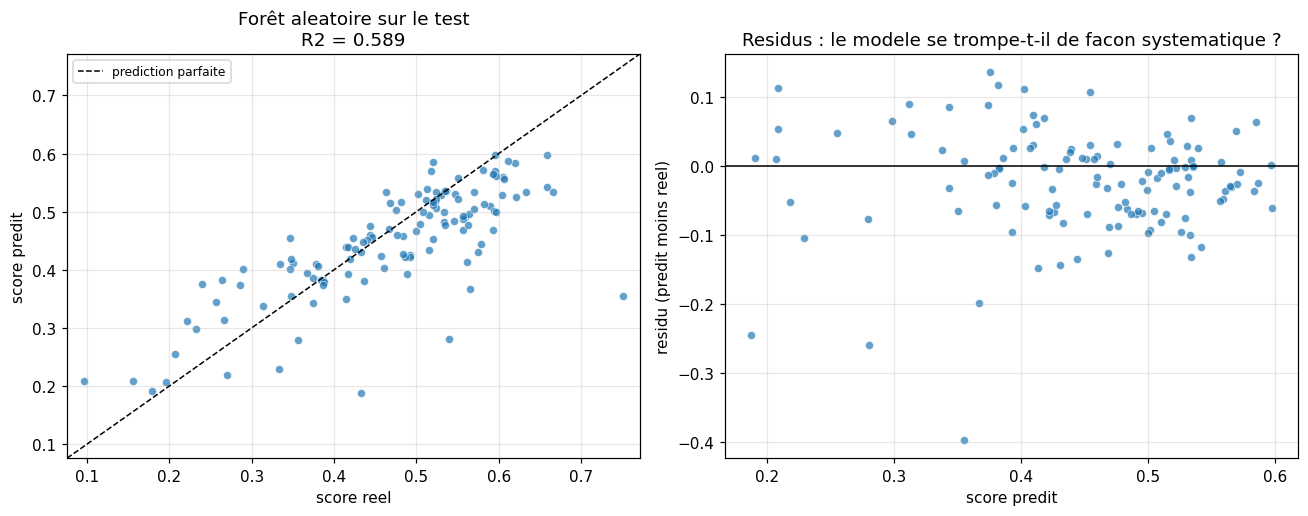

In [21]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

meilleur = resultats_test.index[0]
prediction = predictions_test[meilleur]
axes[0].scatter(y_test_final, prediction, s=28, alpha=0.7,
                edgecolor="white", linewidth=0.5)
limites = [min(y_test_final.min(), prediction.min()) - 0.02,
           max(y_test_final.max(), prediction.max()) + 0.02]
axes[0].plot(limites, limites, "k--", linewidth=1, label="prediction parfaite")
axes[0].set(xlabel="score reel", ylabel="score predit", xlim=limites,
            ylim=limites,
            title=f"{meilleur} sur le test\n"
                  f"R2 = {resultats_test.loc[meilleur, 'R2_groupes']:.3f}")
axes[0].legend(fontsize=8)

residus = prediction - y_test_final
axes[1].scatter(prediction, residus, s=28, alpha=0.7, edgecolor="white",
                linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="score predit", ylabel="residu (predit moins reel)",
            title="Residus : le modele se trompe-t-il de facon systematique ?")

figure.tight_layout()
figure.savefig(OUT / "test_predictions.png", dpi=150)
plt.show()

### Lecture de l'evaluation finale

**La performance sur le test confirme celle de la validation croisee**, ce qui
est le resultat qu'on espere : cela signifie que la procedure de selection n'a
pas surajuste l'ensemble de developpement. Le gain sur la reference est du meme
ordre, voire legerement meilleur.

**Le gain sur la reference depasse celui obtenu avec l'ancienne cible.** La
conclusion de la section 7 tient donc aussi sur des soudures jamais vues, et
pas seulement en validation croisee.

**Une nuance a ne pas cacher : le R2 du test est tres legerement inferieur a
celui obtenu sur l'ancienne cible**, alors que le gain sur la reference, lui,
est superieur. Les deux indicateurs ne se contredisent pas, ils ne se mesurent
simplement pas contre la meme chose. Le R2 compare le modele a la moyenne de
l'ensemble de test **lui-meme**, calculee apres coup. Le gain, lui, le compare a
un predicteur constant ajuste sur le **developpement**, donc sans rien savoir du
test : c'est la situation reelle d'un modele deploye.

Le tableau montre d'ailleurs que ce predicteur constant obtient un R2 negatif
sur le test, ce qui signifie que la moyenne du developpement n'est pas
exactement celle du test. Et avec seulement quatre-vingt-treize soudures de
test, un ecart de un centieme de R2 est du meme ordre que l'incertitude
d'echantillonnage. Il ne faut donc pas l'interpreter.

**Le nuage de points montre une dispersion reelle mais sans biais
systematique.** Les points se repartissent de part et d'autre de la diagonale.
Le graphique des residus confirme l'absence de structure franche : le modele ne
sous-estime pas systematiquement les bonnes soudures ni l'inverse.

On distingue neanmoins une legere contraction vers le centre, les scores
extremes etant predits un peu trop proches de la moyenne. C'est le comportement
normal d'un modele qui predit une esperance conditionnelle, et c'est exactement
l'effet que la section 5 du notebook 08 avait observe en comparant la
classification directe au seuillage d'une regression.

## 9. Les groupes de k-means et la nouvelle cible

Le notebook 07 avait cherche des groupes de soudures par k-means, sans utiliser
la cible, puis avait regarde apres coup si ces groupes correspondaient a des
niveaux de qualite. Sa conclusion etait negative : les groupes refletent des
familles de nuances d'acier et de procedes, pas des niveaux de qualite.

Deux questions se posent ici.

**Les groupes eux-memes changent-ils ?** Non par construction, puisque k-means
ne regarde que les entrees. Mais le nombre de groupes retenu avait ete choisi
par un critere de silhouette, calcule sur l'ensemble des lignes disponibles, et
l'ensemble de lignes a legerement change. On verifie donc que le choix tient.

**Le lien avec la cible change-t-il ?** La, oui potentiellement, puisque la
cible a change.

Un mot sur le **critere de silhouette**, pour que la suite soit lisible. Pour
chaque soudure, on compare sa distance moyenne aux soudures de son propre
groupe a sa distance moyenne aux soudures du groupe voisin le plus proche. Le
score vaut 1 si les groupes sont parfaitement separes, 0 si une soudure est a
egale distance de deux groupes, et il est negatif si elle est plus proche d'un
autre groupe que du sien. On retient le nombre de groupes qui maximise la
moyenne de ce score.

In [22]:
preparation_kmeans, _ = creer_preparation(X_dev)
X_dev_prepare = preparation_kmeans.fit_transform(X_dev)

lignes_silhouette = []
for k in range(2, 9):
    modele_kmeans = KMeans(n_clusters=k, n_init=20,
                           random_state=GRAINE).fit(X_dev_prepare)
    lignes_silhouette.append({
        "k": k,
        "silhouette": silhouette_score(X_dev_prepare, modele_kmeans.labels_),
        "inertie": modele_kmeans.inertia_,
    })

choix_k = pd.DataFrame(lignes_silhouette).set_index("k")
k_retenu = int(choix_k["silhouette"].idxmax())
bilan_07 = json.loads((ROOT / "outputs/07/bilan.json").read_text(encoding="utf-8"))

print(f"k retenu ici              : {k_retenu}")
print(f"k retenu par le notebook 07 : {bilan_07['k_retenu']}")
choix_k.round(4)

k retenu ici              : 4
k retenu par le notebook 07 : 4


,silhouette,inertie
k,,
2,0.2660,10211.3986
3,0.2938,8686.5691
4,0.3140,8023.6551
5,0.1675,7561.3448
6,0.1718,6944.5181
7,0.3014,6595.0950
8,0.2003,6108.3294


In [23]:
kmeans = KMeans(n_clusters=k_retenu, n_init=20,
                random_state=GRAINE).fit(X_dev_prepare)
appartenance = pd.Series(kmeans.labels_, index=X_dev.index, name="groupe_kmeans")

table_clusters = pd.DataFrame({
    "groupe_kmeans": appartenance,
    "score": y_dev_final,
    "soudure": G_dev,
})
resume_clusters = table_clusters.groupby("groupe_kmeans").agg(
    lignes=("score", "size"),
    soudures=("soudure", "nunique"),
    score_moyen=("score", "mean"),
    score_ecart_type=("score", "std"),
    score_minimum=("score", "min"),
    score_maximum=("score", "max"),
)

# Le groupe suffit-il a predire le score ? On predit la moyenne de son groupe.
moyennes_par_groupe = table_clusters.groupby("groupe_kmeans")["score"].mean()
prediction_par_groupe = appartenance.map(moyennes_par_groupe)
poids_dev = poids_groupes(G_dev)

rmse_par_groupe = np.sqrt(mean_squared_error(y_dev_final, prediction_par_groupe,
                                             sample_weight=poids_dev))
gain_kmeans = 1 - rmse_par_groupe / RMSE_REFERENCE

print(f"RMSE en predisant la moyenne du groupe k-means : {rmse_par_groupe:.4f}")
print(f"RMSE de la reference constante                 : {RMSE_REFERENCE:.4f}")
print(f"RMSE de la forêt aleatoire                     : "
      f"{foret.iloc[0]['RMSE_groupes']:.4f}")
print(f"\nGain du groupe k-means sur la reference : {gain_kmeans:.1%}")
print(f"Gain de la forêt aleatoire             : "
      f"{1 - foret.iloc[0]['RMSE_groupes'] / RMSE_REFERENCE:.1%}")
resume_clusters.round(3)

RMSE en predisant la moyenne du groupe k-means : 0.1221


RMSE de la reference constante                 : 0.1318
RMSE de la forêt aleatoire                     : 0.0817

Gain du groupe k-means sur la reference : 7.3%
Gain de la forêt aleatoire             : 38.0%


,lignes,soudures,score_moyen,score_ecart_type,score_minimum,score_maximum
groupe_kmeans,,,,,,
0,357,250,0.447,0.128,0.036,0.676
1,108,77,0.362,0.122,0.083,0.718
2,33,28,0.338,0.117,0.053,0.508
3,29,24,0.353,0.123,0.125,0.662


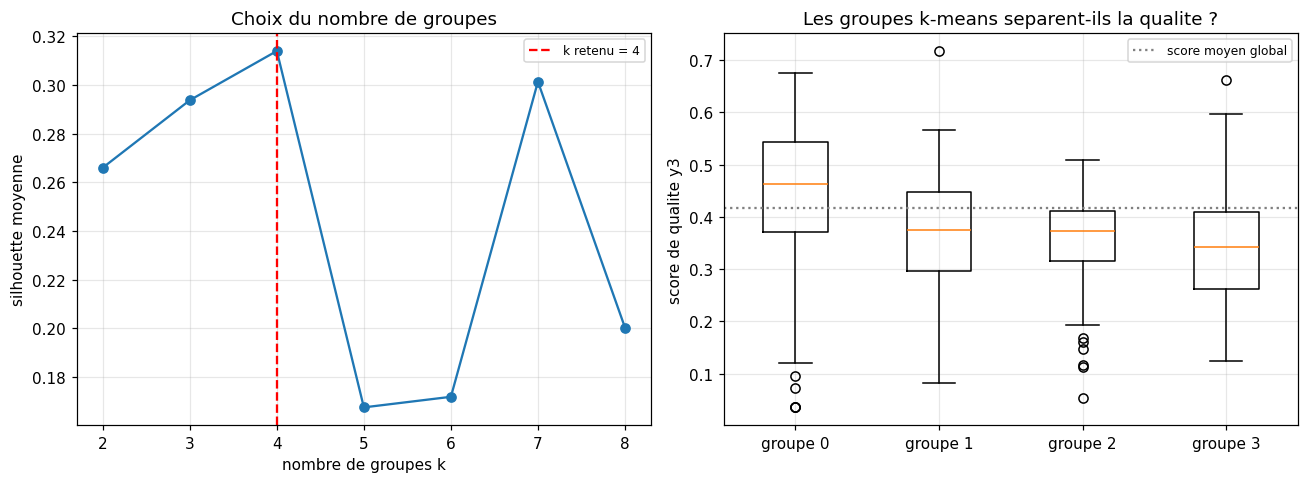

In [24]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(choix_k.index, choix_k["silhouette"], marker="o")
axes[0].axvline(k_retenu, color="red", linestyle="--",
                label=f"k retenu = {k_retenu}")
axes[0].set(xlabel="nombre de groupes k", ylabel="silhouette moyenne",
            title="Choix du nombre de groupes")
axes[0].legend(fontsize=8)

donnees_boites = [table_clusters.loc[table_clusters["groupe_kmeans"] == g,
                                     "score"].to_numpy()
                  for g in sorted(appartenance.unique())]
axes[1].boxplot(donnees_boites, tick_labels=[f"groupe {g}" for g in
                                             sorted(appartenance.unique())])
axes[1].axhline(y_dev_final.mean(), color="grey", linestyle=":",
                label="score moyen global")
axes[1].set(ylabel="score de qualite y3",
            title="Les groupes k-means separent-ils la qualite ?")
axes[1].legend(fontsize=8)

figure.tight_layout()
figure.savefig(OUT / "kmeans_et_cible.png", dpi=150)
plt.show()

### Conclusion de la section 9

**Le nombre de groupes retenu est le meme que celui du notebook 07.** Le
changement de cible, et le leger changement d'effectif qui l'accompagne, ne
modifient pas la structure trouvee dans les entrees. C'est coherent avec la
section 3 : les entrees ne bougent pas.

**La conclusion du notebook 07 reste valable, et c'est une conclusion
negative.** Les boites se recouvrent largement : chaque groupe k-means contient
des soudures de toutes qualites. Predire la moyenne du groupe ne fait gagner
qu'une faible fraction de l'erreur de la reference, tres loin de ce qu'obtient
la forêt aleatoire.

**Pourquoi cela n'est pas un echec.** Un resultat negatif bien etabli est un
resultat. Il dit quelque chose de precis sur le probleme : **les regroupements
naturels des soudures ne sont pas des regroupements de qualite.** Deux soudures
de composition voisine, donc dans le meme groupe k-means, peuvent avoir des
qualites tres differentes, parce que ce sont des details du procede et du
traitement thermique qui font la difference. C'est d'ailleurs coherent avec la
section 4.4 du notebook 08, qui montrait que le traitement thermique
post-soudage est l'une des variables les plus importantes pour predire `y3`.

Cela justifie aussi, a posteriori, l'approche supervisee : il faut un modele qui
apprenne le lien entre entrees et qualite, un decoupage non supervise de
l'espace des compositions ne suffit pas.

## 10. Conclusion

### 10.1 Ce que ce notebook etablit

**Sur l'etendue du changement.** Le passage a la nouvelle cible n'affecte ni la
preparation des entrees, ni l'analyse en composantes principales, ni la
structure trouvee par k-means. Les notebooks 03, 04 et 07 n'ont donc pas besoin
d'etre refaits, et cela a ete verifie plutot que suppose. Seuls les modeles
supervises sont concernes, et ils ont ete reentraines ici avec les grilles
completes des notebooks 05 et 06.

**Sur la performance.** Tous les modeles obtiennent un meilleur gain sur la
reference avec la nouvelle cible qu'avec l'ancienne. L'ecart est net pour les
methodes a base d'arbres. Le resultat est confirme sur l'ensemble de test, qui
n'avait jamais ete utilise pour la nouvelle cible.

**Sur le choix du modele.** Le classement des familles est inchange : les
methodes d'ensemble devant, puis les k plus proches voisins, puis les lineaires
penalisees, enfin l'arbre seul et la regression lineaire simple. Les
conclusions des notebooks 05 et 06 sur ce point restent valables.

**Sur les hyperparametres.** Les optima ne sont pas exactement les memes qu'avec
l'ancienne cible. Il faut donc les reajuster quand on change de cible, et non
les reprendre tels quels.

### 10.2 Ce qu'il reste a faire

**Le boosting n'a pas ete teste**, ni ici ni ailleurs dans le projet. C'est la
seule famille du cours absente, et c'est la premiere chose a ajouter. Elle
s'applique directement au jeu de donnees produit par le notebook 08.

**Les grilles de la forêt et du bagging gardent des optima proches de leurs
bords**, notamment sur la profondeur maximale et la proportion de variables
candidates. Les elargir permettrait de verifier que l'optimum est bien interne.

**L'etude complete des modeles de classification** reste a mener, selon le
programme detaille en section 5.4 du notebook 08.

**Une methode semi-supervisee** pourrait exploiter les lignes sans cible, qui
restent nombreuses et portent pourtant une composition et un procede complets.

### 10.3 En une phrase

Le changement de cible decide par le notebook 08 ne coute rien et rapporte
partout : il ne remet en cause aucune des etapes de preparation, il ne modifie
pas le classement des modeles, et il ameliore la performance de chacun d'entre
eux, en validation croisee comme sur l'ensemble de test.

In [25]:
toutes_configurations = pd.concat(familles.values(), ignore_index=True)
toutes_configurations["parametres"] = toutes_configurations["parametres"].astype(str)
toutes_configurations.to_csv(OUT / "toutes_configurations.csv", index=False)

comparaison.to_csv(OUT / "comparaison_cibles.csv", index_label="modele")
resultats_test.to_csv(OUT / "resultats_test.csv", index_label="modele")
bilan_final.to_csv(OUT / "bilan_final.csv", index_label="indicateur")
comparaison_acp.to_csv(OUT / "acp_invariance.csv", index_label="cible")
comparaison_medianes.to_csv(OUT / "medianes_imputation.csv",
                            index_label="variable")
resume_clusters.to_csv(OUT / "kmeans_et_cible.csv", index_label="groupe_kmeans")
choix_k.to_csv(OUT / "kmeans_choix_k.csv", index_label="k")
pd.DataFrame({"soudure": G_test, "score_reel": y_test_final,
              **predictions_test}).to_csv(OUT / "predictions_test.csv",
                                          index_label="row_id")

def convertir(objet):
    if isinstance(objet, np.generic):
        return objet.item()
    raise TypeError(type(objet).__name__)

bilan = {
    "graine": GRAINE,
    "sklearn": version_sklearn,
    "cible": "y3",
    "source": "outputs/08/dataset_traction_y3.csv",
    "remplace": "outputs/02/dataset_traction.csv",
    "selection_colonnes_identique_a_y2": bool(identiques),
    "k_kmeans_retenu": k_retenu,
    "configurations_testees": int(len(toutes_configurations) - len(reference)),
    "modele_retenu": resultats_test.index[0],
    "hyperparametres_retenus": {
        nom: str(table.iloc[0]["parametres"]) for nom, table in familles.items()},
    "RMSE_validation_groupes": {
        nom: float(table.iloc[0]["RMSE_groupes"])
        for nom, table in familles.items()},
    "gain_validation_sur_reference": {
        nom: float(1 - table.iloc[0]["RMSE_groupes"] / RMSE_REFERENCE)
        for nom, table in familles.items()},
    "test": resultats_test.to_dict(orient="index"),
    "regle_selection": ("plus petite moyenne des cinq RMSE par groupes "
                        "sur developpement"),
}
(OUT / "bilan.json").write_text(
    json.dumps(bilan, ensure_ascii=False, indent=2, default=convertir),
    encoding="utf-8")

print(f"Notebook 09 termine en {time.time() - depart_total:.0f} s de calcul.")
print(f"\nFichiers produits dans {OUT.relative_to(ROOT)} :")
for chemin in sorted(OUT.iterdir()):
    print(f"   {chemin.name:38s} {chemin.stat().st_size / 1024:7.1f} ko")

Notebook 09 termine en 352 s de calcul.

Fichiers produits dans outputs\09 :
   acp_invariance.csv                         0.2 ko
   acp_invariance.png                        60.2 ko
   arbres_reglages.png                       77.7 ko
   bilan.json                                 3.4 ko
   bilan_final.csv                            0.4 ko
   comparaison_cibles.csv                     1.4 ko
   comparaison_cibles_modeles.png            69.5 ko
   kmeans_choix_k.csv                         0.3 ko
   kmeans_et_cible.csv                        0.4 ko
   kmeans_et_cible.png                       88.2 ko
   lineaires_knn_reglages.png               161.4 ko
   medianes_imputation.csv                    0.8 ko
   predictions_test.csv                      17.3 ko
   resultats_test.csv                         0.7 ko
   test_predictions.png                      88.5 ko
   toutes_configurations.csv                117.9 ko
